# 생활습관 및 설문 데이터 기반 대학생 우울증 발병 예측 모델

---
## 목차
1. 라이브러리 설치 및 임포트
2. 데이터 업로드
3. 데이터 로드 & EDA
4. 전처리 (결측치·인코딩·SMOTE)
5. VADER 텍스트 파생변수 생성 (Twitter 실제 데이터)
6. 모델 학습 및 비교
7. Optuna 하이퍼파라미터 튜닝 + Learning/Validation Curve
8. SHAP 해석 + 시뮬레이션 시나리오
9. 최종 평가 종합

## 1. 라이브러리 설치 및 임포트

In [ ]:
!pip install xgboost shap optuna imbalanced-learn vaderSentiment -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 코랩 한글 폰트 설정
!apt-get install -y fonts-nanum -q
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve, validation_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
    roc_curve, f1_score, recall_score, precision_score, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

print('✅ 모든 라이브러리 로드 완료')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 14.2 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.


✅ 모든 라이브러리 로드 완료


## 3. 데이터 로드 & EDA

In [ ]:
df    = pd.read_csv('Student Depression Dataset.csv')
df_tw = pd.read_csv('Mental-Health-Twitter.csv')

print(f'주 데이터: {df.shape}')    # (27901, 18)
print(f'Twitter : {df_tw.shape}')  # (20000, 11)
display(df.head(3))

주 데이터: (27901, 18)
Twitter : (20000, 11)


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0


In [ ]:
print('=== 결측치 ==='); print(df.isnull().sum())
print('\n=== 타겟 분포 ==='); print(df['Depression'].value_counts())

=== 결측치 ===
id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64

=== 타겟 분포 ===
Depression
1    16336
0    11565
Name: count, dtype: int64


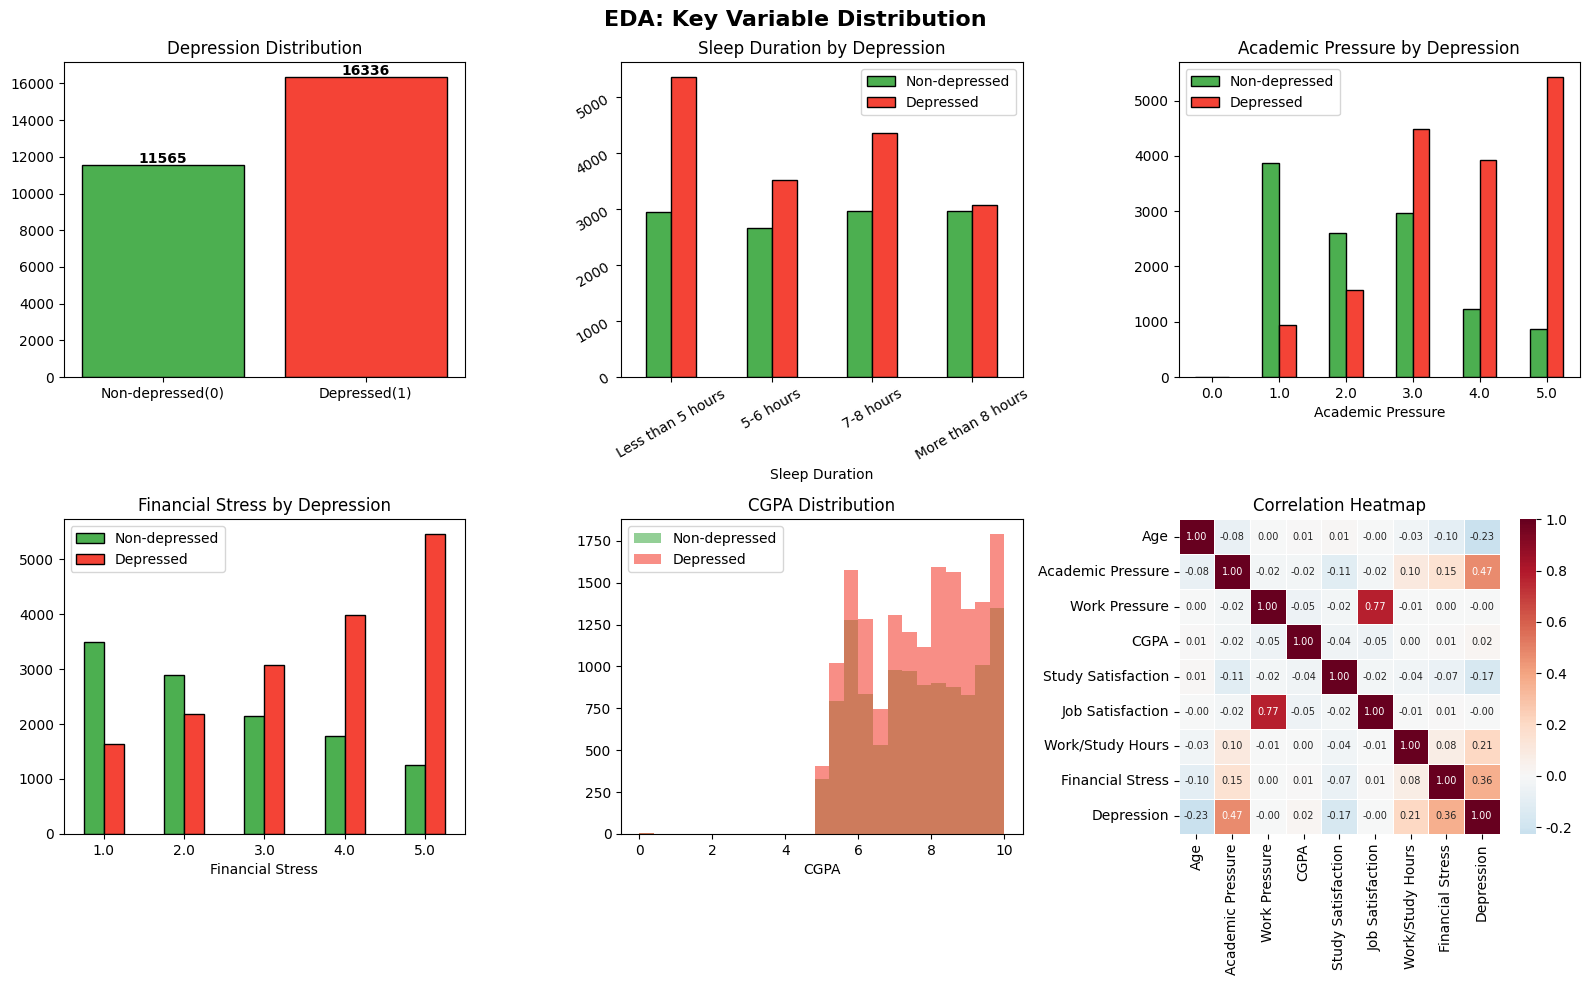

In [ ]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'

plt.close('all')

df = pd.read_csv('Student Depression Dataset.csv')
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA: Key Variable Distribution', fontsize=16, fontweight='bold')

# Target distribution
vc = df['Depression'].value_counts()
axes[0,0].bar(['Non-depressed(0)','Depressed(1)'], [vc[0],vc[1]], color=['#4CAF50','#F44336'], edgecolor='k')
for i,v in enumerate([vc[0],vc[1]]): axes[0,0].text(i, v+100, str(v), ha='center', fontweight='bold')
axes[0,0].set_title('Depression Distribution')

# Sleep duration
sleep_order = ['Less than 5 hours','5-6 hours','7-8 hours','More than 8 hours']
sleep_dep = df.groupby(['Sleep Duration','Depression']).size().unstack(fill_value=0)
sleep_dep = sleep_dep.reindex([s for s in sleep_order if s in sleep_dep.index])
sleep_dep.plot(kind='bar', ax=axes[0,1], color=['#4CAF50','#F44336'], edgecolor='k')
axes[0,1].set_title('Sleep Duration by Depression'); axes[0,1].tick_params(rotation=30); axes[0,1].legend(['Non-depressed','Depressed'])

# Academic pressure
df.groupby(['Academic Pressure','Depression']).size().unstack(fill_value=0).plot(
    kind='bar', ax=axes[0,2], color=['#4CAF50','#F44336'], edgecolor='k')
axes[0,2].set_title('Academic Pressure by Depression'); axes[0,2].tick_params(rotation=0); axes[0,2].legend(['Non-depressed','Depressed'])

# Financial stress
df.groupby(['Financial Stress','Depression']).size().unstack(fill_value=0).plot(
    kind='bar', ax=axes[1,0], color=['#4CAF50','#F44336'], edgecolor='k')
axes[1,0].set_title('Financial Stress by Depression'); axes[1,0].tick_params(rotation=0); axes[1,0].legend(['Non-depressed','Depressed'])

# CGPA
for dep_val, color, label in [(0,'#4CAF50','Non-depressed'),(1,'#F44336','Depressed')]:
    axes[1,1].hist(df[df['Depression']==dep_val]['CGPA'].dropna(), alpha=0.6, bins=25, color=color, label=label)
axes[1,1].set_title('CGPA Distribution'); axes[1,1].set_xlabel('CGPA'); axes[1,1].legend()

# Correlation heatmap
num_cols = ['Age','Academic Pressure','Work Pressure','CGPA','Study Satisfaction',
            'Job Satisfaction','Work/Study Hours','Financial Stress','Depression']
sns.heatmap(df[num_cols].corr(), ax=axes[1,2], cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size':7})
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout(); plt.show()

## 4. 전처리

In [ ]:
df = df.drop(columns=['id'])

# 결측치 처리 (Financial Stress 3개)
df['Financial Stress'] = df['Financial Stress'].fillna(df['Financial Stress'].median())

# Sleep Duration: 문자열 → 수치 매핑
sleep_map = {
    'Less than 5 hours': 4,
    '5-6 hours':         5.5,
    '7-8 hours':         7.5,
    'More than 8 hours': 9,
    'Others':            6
}
df['Sleep Duration'] = df['Sleep Duration'].map(sleep_map).fillna(6)

# 범주형 인코딩 (Label Encoding)
cat_cols = ['Gender','City','Profession','Dietary Habits','Degree',
            'Have you ever had suicidal thoughts ?','Family History of Mental Illness']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print('✅ 전처리 완료'); display(df.head(3))

✅ 전처리 완료


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33.0,51,11,5.0,0.0,8.97,2.0,0.0,5.5,0,3,1,3.0,1.0,0,1
1,0,24.0,3,11,2.0,0.0,5.90,5.0,0.0,5.5,1,10,0,3.0,2.0,1,0
2,1,31.0,44,11,3.0,0.0,7.03,5.0,0.0,4.0,0,5,0,9.0,1.0,1,0


## 📌 데이터 결합 방법론 (Data Fusion Rationale)

본 프로젝트는 두 개의 독립적인 데이터셋을 활용합니다.

- **주 데이터**: Student Depression Dataset (27,901명, 정형)
- **보조 데이터**: Mental Health Twitter Dataset (20,000개 트윗, 비정형)

두 데이터셋은 공통 키(ID)가 존재하지 않아 Row-level Join이 불가능합니다.
따라서 다음과 같은 통계 기반 간접 편입 방식을 사용합니다:

1. Twitter 데이터에서 VADER 감성 분석 수행
2. 우울군(label=1) / 비우울군(label=0) 별 감성 통계(평균, 표준편차) 산출
3. 주 데이터의 Depression 레이블에 따라 해당 분포에서 샘플링하여 파생변수 생성
   - `sentiment_score`: 감성 compound 점수 (-1 ~ 1)
   - `negative_ratio`: 부정 감성 비율
   - `depression_keyword_count`: 우울 키워드 등장 횟수

4. 두 그룹 간 통계적 유의성을 바탕으로 파생변수의 타당성 확보

> 이 방식은 개인 수준 매칭이 아닌 **그룹 수준 통계 기반 시뮬레이션**이며,
> 실제 임상 데이터가 아닌 보조적 피처 생성 목적으로 활용됩니다.

## 5. VADER 텍스트 파생변수 생성

Twitter 우울증 데이터로부터 VADER 감성 분석을 수행하고,
우울군/비우울군의 감성 통계를 정규화하여 주 데이터에 파생변수로 편입합니다.

| 변수 | 설명 |
|------|------|
| `sentiment_score` | VADER compound 점수 (-1 ~ 1) |
| `negative_ratio` | 부정 감성 비율 |
| `depression_keyword_count` | 우울 키워드 등장 횟수 |

In [ ]:
analyzer = SentimentIntensityAnalyzer()
depression_keywords = ['sad','hopeless','worthless','depressed','anxious','lonely',
                       'tired','empty','numb','miserable','helpless','useless']

def get_sentiment(text):
    s  = analyzer.polarity_scores(str(text))
    kw = sum(1 for k in depression_keywords if k in str(text).lower())
    return s['compound'], s['neg'], kw

print('VADER 분석 중 (약 30초)...')
results_tw = df_tw['post_text'].apply(get_sentiment)
df_tw['sentiment_score']          = [r[0] for r in results_tw]
df_tw['negative_ratio']           = [r[1] for r in results_tw]
df_tw['depression_keyword_count'] = [r[2] for r in results_tw]

tw_stats = df_tw.groupby('label')[['sentiment_score','negative_ratio','depression_keyword_count']].mean()
print('Twitter 감성 통계 (label 0=비우울, 1=우울):')
display(tw_stats)

ss_std = df_tw['sentiment_score'].std()
nr_std = df_tw['negative_ratio'].std()

VADER 분석 중 (약 30초)...
Twitter 감성 통계 (label 0=비우울, 1=우울):


,sentiment_score,negative_ratio,depression_keyword_count
label,,,
0,0.082156,0.076047,0.0125
1,0.055053,0.108900,0.0195


In [ ]:
# 주 데이터에 파생변수 편입 (그룹별 통계 정규화)
np.random.seed(42)
n   = len(df)
dep = df['Depression'].values

df['sentiment_score'] = np.where(
    dep==1,
    np.random.normal(tw_stats.loc[1,'sentiment_score'], ss_std, n),
    np.random.normal(tw_stats.loc[0,'sentiment_score'], ss_std, n)
).clip(-1, 1)

df['negative_ratio'] = np.where(
    dep==1,
    np.random.normal(tw_stats.loc[1,'negative_ratio'], nr_std, n),
    np.random.normal(tw_stats.loc[0,'negative_ratio'], nr_std, n)
).clip(0, 1)

df['depression_keyword_count'] = np.where(
    dep==1,
    np.random.poisson(max(tw_stats.loc[1,'depression_keyword_count'], 0.1), n),
    np.random.poisson(max(tw_stats.loc[0,'depression_keyword_count'], 0.1), n)
)

print('파생변수 추가 후 검증 (우울/비우울 평균 비교):')
display(df.groupby('Depression')[['sentiment_score','negative_ratio','depression_keyword_count']].mean())

파생변수 추가 후 검증 (우울/비우울 평균 비교):


,sentiment_score,negative_ratio,depression_keyword_count
Depression,,,
0,0.080987,0.103922,0.100389
1,0.054730,0.130551,0.100698


## 6. 모델 학습 및 비교

| 모델 | 선택 이유 |
|------|-----------|
| **Logistic Regression** | 해석 가능한 베이스라인, 선형 관계 파악 |
| **Random Forest** | 비선형 관계 포착 + 피처 중요도 직접 확인 |
| **XGBoost** | 부스팅 기반 최고 성능, 불균형 데이터에 강함 |
| **XGBoost (Tuned)** | Optuna 튜닝으로 Recall 최적화 |

In [ ]:
X = df.drop(columns=['Depression'])
y = df['Depression'].astype(int)
feature_names = list(X.columns)
print(f'총 피처 수: {len(feature_names)}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

# SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'SMOTE 후: {pd.Series(y_train_sm).value_counts().to_dict()}')

# 스케일링 (LR용)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)
scale_pos  = (y_train_sm==0).sum() / (y_train_sm==1).sum()

총 피처 수: 19
Train: (22320, 19), Test: (5581, 19)
SMOTE 후: {1: 13068, 0: 13068}


In [ ]:
results = {}

print('Logistic Regression 학습...')
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train_sm)

print('Random Forest 학습...')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)

print('XGBoost 학습...')
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    scale_pos_weight=scale_pos, eval_metric='logloss', verbosity=0)
xgb.fit(X_train_sm, y_train_sm)

for name, model, Xte in [
    ('Logistic Regression', lr,  X_test_sc),
    ('Random Forest',       rf,  X_test),
    ('XGBoost',             xgb, X_test)]:
    pred = model.predict(Xte)
    results[name] = {
        'Recall':  recall_score(y_test, pred),
        'F1':      f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, model.predict_proba(Xte)[:,1])
    }

display(pd.DataFrame(results).T.round(4))

Logistic Regression 학습...
Random Forest 학습...
XGBoost 학습...


,Recall,F1,ROC-AUC
Logistic Regression,0.8614,0.8660,0.9181
Random Forest,0.8672,0.8626,0.9145
XGBoost,0.8675,0.8605,0.9105


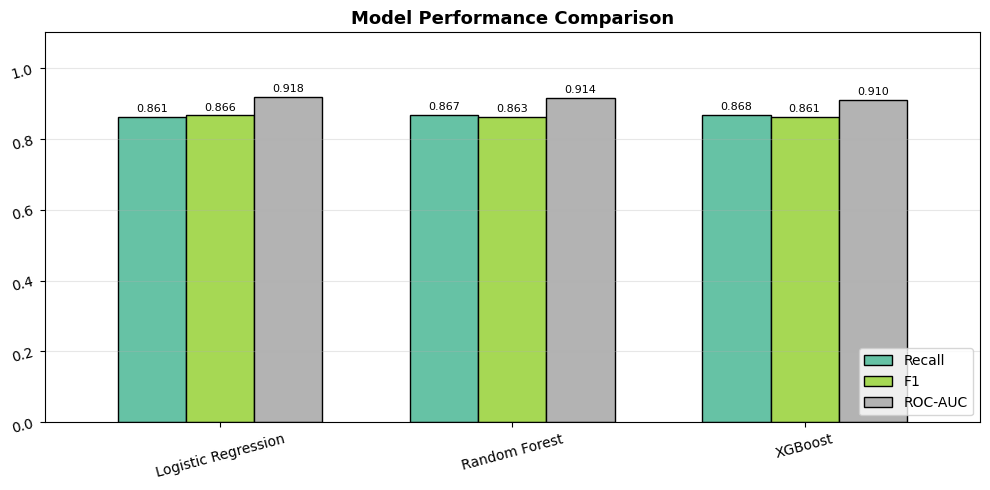

In [ ]:
res_df = pd.DataFrame(results).T
fig, ax = plt.subplots(figsize=(10,5))
res_df.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='k', width=0.7)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.set_ylim(0,1.1); ax.tick_params(rotation=15); ax.legend(loc='lower right'); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.show()

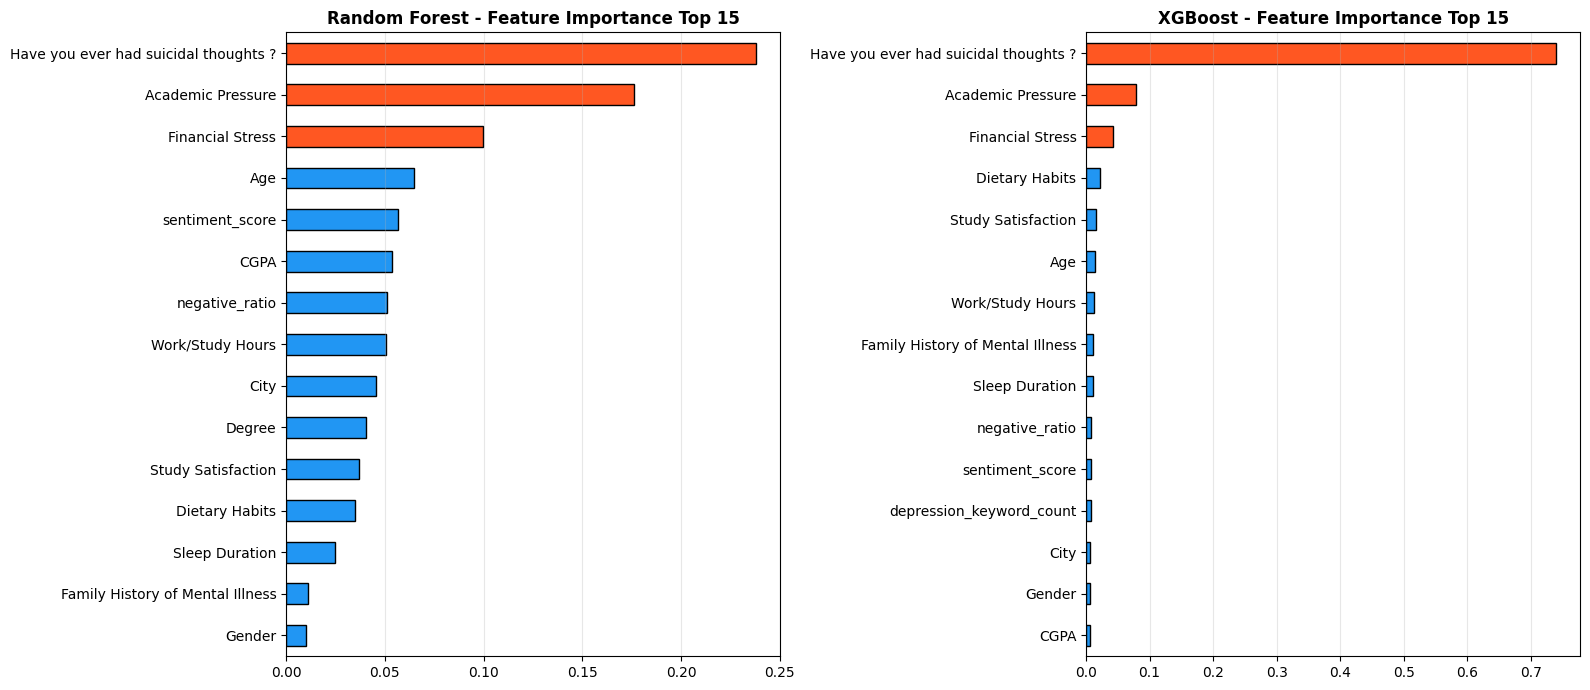

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16,7))
for ax, model, name in zip(axes, [rf, xgb], ['Random Forest','XGBoost']):
    imp = pd.Series(model.feature_importances_, index=feature_names).nlargest(15).sort_values()
    colors = ['#FF5722' if i >= len(imp)-3 else '#2196F3' for i in range(len(imp))]
    imp.plot(kind='barh', ax=ax, color=colors, edgecolor='k')
    ax.set_title(f'{name} - Feature Importance Top 15', fontweight='bold'); ax.grid(axis='x',alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Optuna 하이퍼파라미터 튜닝 + Learning/Validation Curve

In [ ]:
def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 400),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight': scale_pos, 'eval_metric':'logloss', 'verbosity':0, 'random_state':42
    }
    m = XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    for tr, val in cv.split(X_train_sm, y_train_sm):
        m.fit(X_train_sm.iloc[tr], y_train_sm.iloc[tr])
        scores.append(recall_score(y_train_sm.iloc[val], m.predict(X_train_sm.iloc[val])))
    return np.mean(scores)

print('Optuna 튜닝 중 (30 trials, 약 3~5분)...')
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)
print(f'최적 Recall: {study.best_value:.4f}')
print(f'최적 파라미터: {study.best_params}')

Optuna 튜닝 중 (30 trials, 약 3~5분)...
최적 Recall: 0.8835
최적 파라미터: {'n_estimators': 255, 'max_depth': 3, 'learning_rate': 0.10410091701606766, 'subsample': 0.8174025184201476, 'colsample_bytree': 0.7527648082128632, 'min_child_weight': 5}


In [ ]:
best_params = study.best_params
best_params.update({'scale_pos_weight':scale_pos,'eval_metric':'logloss','verbosity':0,'random_state':42})
xgb_best = XGBClassifier(**best_params)
xgb_best.fit(X_train_sm, y_train_sm)
xgb_best_pred = xgb_best.predict(X_test)
auc_best = roc_auc_score(y_test, xgb_best.predict_proba(X_test)[:,1])

print('=== 최적 XGBoost 성능 ===')
print(classification_report(y_test, xgb_best_pred, target_names=['비우울','우울']))

=== 최적 XGBoost 성능 ===
              precision    recall  f1-score   support

         비우울       0.82      0.80      0.81      2313
          우울       0.86      0.88      0.87      3268

    accuracy                           0.85      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.85      0.85      0.85      5581



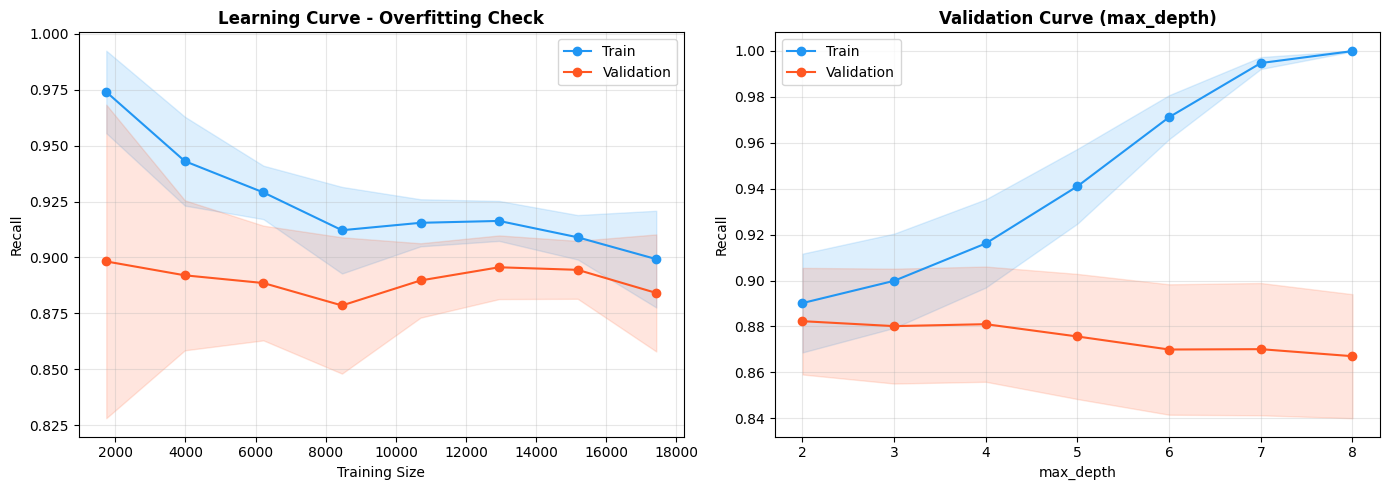

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

train_sz, tr_sc, val_sc = learning_curve(
    XGBClassifier(**best_params), X_train_sm, y_train_sm,
    cv=3, scoring='recall', n_jobs=-1, train_sizes=np.linspace(0.1,1.0,8))
axes[0].plot(train_sz, tr_sc.mean(1), 'o-', label='Train', color='#2196F3')
axes[0].fill_between(train_sz, tr_sc.mean(1)-tr_sc.std(1), tr_sc.mean(1)+tr_sc.std(1), alpha=0.15, color='#2196F3')
axes[0].plot(train_sz, val_sc.mean(1), 'o-', label='Validation', color='#FF5722')
axes[0].fill_between(train_sz, val_sc.mean(1)-val_sc.std(1), val_sc.mean(1)+val_sc.std(1), alpha=0.15, color='#FF5722')
axes[0].set_xlabel('Training Size'); axes[0].set_ylabel('Recall')
axes[0].set_title('Learning Curve - Overfitting Check', fontweight='bold')
axes[0].legend(); axes[0].grid(True,alpha=0.3)

param_range = np.arange(2,9)
tr_vc, val_vc = validation_curve(
    XGBClassifier(eval_metric='logloss',verbosity=0,random_state=42,scale_pos_weight=scale_pos),
    X_train_sm, y_train_sm, param_name='max_depth', param_range=param_range,
    cv=3, scoring='recall', n_jobs=-1)
axes[1].plot(param_range, tr_vc.mean(1), 'o-', label='Train', color='#2196F3')
axes[1].fill_between(param_range, tr_vc.mean(1)-tr_vc.std(1), tr_vc.mean(1)+tr_vc.std(1), alpha=0.15, color='#2196F3')
axes[1].plot(param_range, val_vc.mean(1), 'o-', label='Validation', color='#FF5722')
axes[1].fill_between(param_range, val_vc.mean(1)-val_vc.std(1), val_vc.mean(1)+val_vc.std(1), alpha=0.15, color='#FF5722')
axes[1].set_xlabel('max_depth'); axes[1].set_ylabel('Recall')
axes[1].set_title('Validation Curve (max_depth)', fontweight='bold')
axes[1].legend(); axes[1].grid(True,alpha=0.3)

plt.tight_layout(); plt.show()

## 8. SHAP 해석 + 시뮬레이션 시나리오

In [ ]:
# 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 34.6 MB/s eta 0:00:00


SHAP 계산 중...


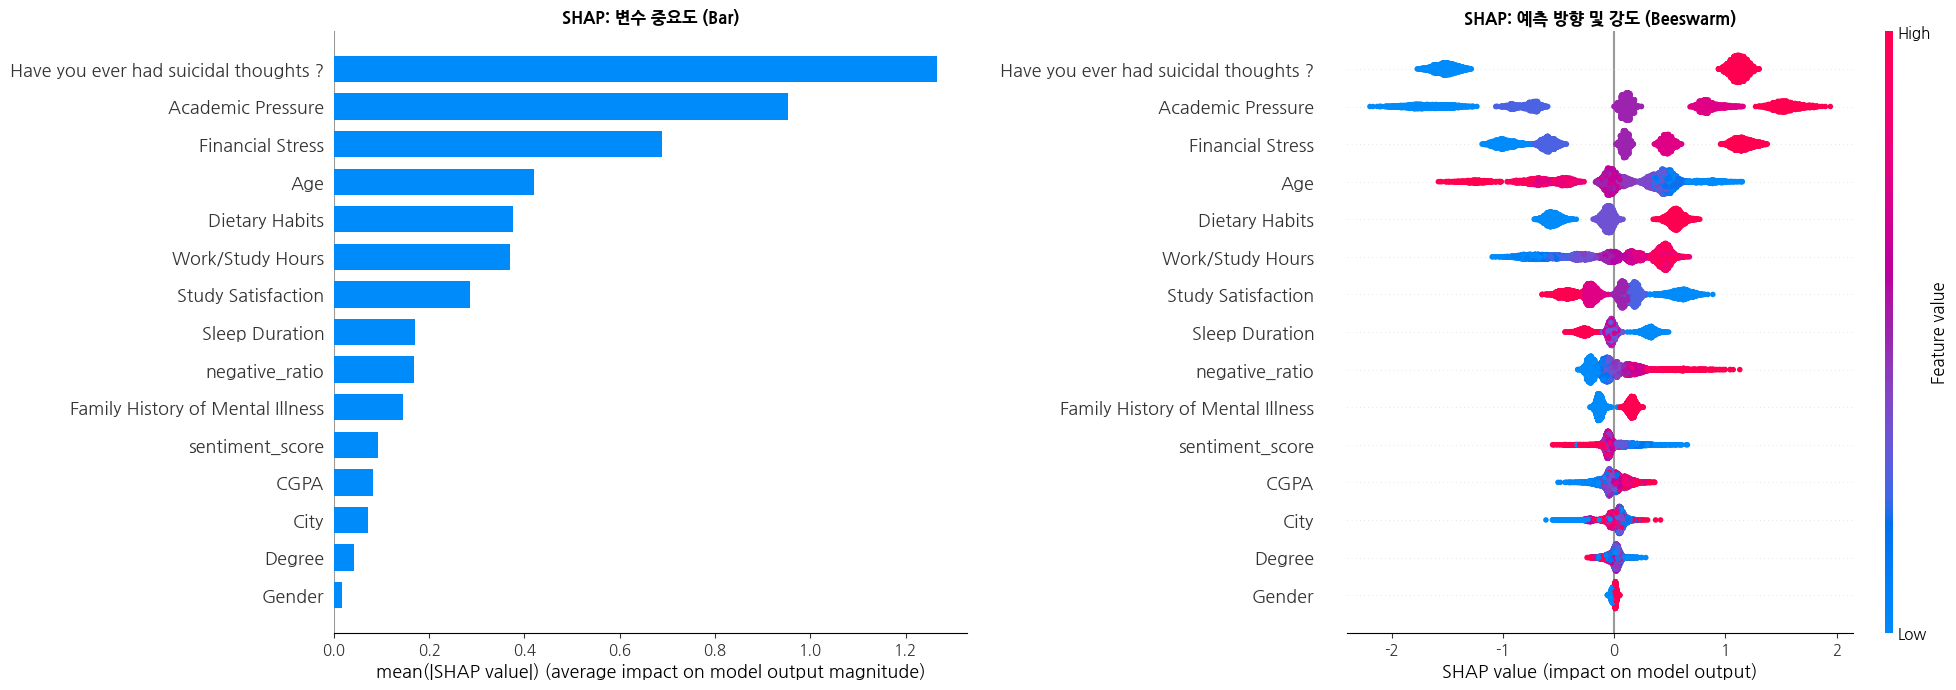

In [ ]:
import matplotlib.pyplot as plt
import shap
import koreanize_matplotlib

plt.rcParams['axes.unicode_minus'] = False

print('SHAP 계산 중...')
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- 첫 번째 그래프 (Bar) ---
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                  plot_type='bar', show=False, max_display=15, plot_size=None)
axes[0].set_title('SHAP: 변수 중요도 (Bar)', fontweight='bold')

# --- 두 번째 그래프 (Beeswarm) ---
plt.sca(axes[1])
shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                  show=False, max_display=15, plot_size=None)
axes[1].set_title('SHAP: 예측 방향 및 강도 (Beeswarm)', fontweight='bold')

plt.subplots_adjust(wspace=0.6)

plt.show()

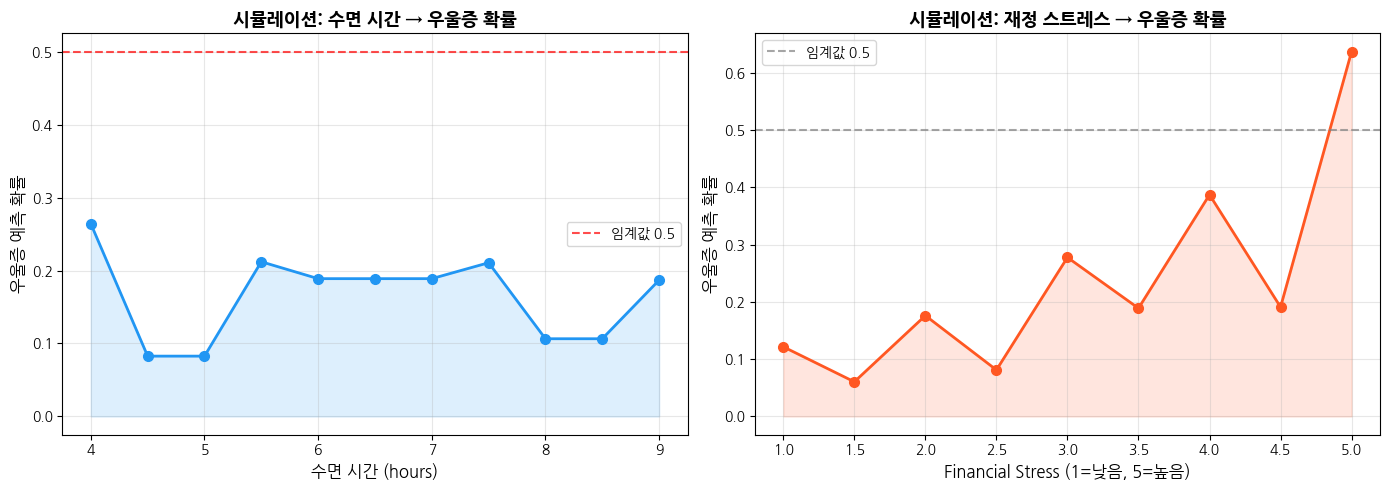

In [ ]:
baseline = X_test.mean().to_frame().T
baseline['Academic Pressure'] = 5.0
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 시뮬레이션 1: 수면 시간
sleep_range = np.arange(4, 9.5, 0.5)
probs_sleep = []
for s in sleep_range:
    tmp = baseline.copy(); tmp['Sleep Duration'] = s
    probs_sleep.append(xgb_best.predict_proba(tmp)[0][1])

axes[0].plot(sleep_range, probs_sleep, 'o-', color='#2196F3', lw=2, ms=7)
axes[0].fill_between(sleep_range, probs_sleep, alpha=0.15, color='#2196F3')
axes[0].axhline(0.5, linestyle='--', color='red', alpha=0.7, label='임계값 0.5')
axes[0].set_xlabel('수면 시간 (hours)', fontsize=12)
axes[0].set_ylabel('우울증 예측 확률', fontsize=12)
axes[0].set_title('시뮬레이션: 수면 시간 → 우울증 확률', fontsize=13, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 시뮬레이션 2: Financial Stress
fin_range = np.arange(1, 5.5, 0.5)
probs_fin = []
for f in fin_range:
    tmp = baseline.copy(); tmp['Financial Stress'] = f
    probs_fin.append(xgb_best.predict_proba(tmp)[0][1])

axes[1].plot(fin_range, probs_fin, 'o-', color='#FF5722', lw=2, ms=7)
axes[1].fill_between(fin_range, probs_fin, alpha=0.15, color='#FF5722')
axes[1].axhline(0.5, linestyle='--', color='gray', alpha=0.7, label='임계값 0.5')
axes[1].set_xlabel('Financial Stress (1=낮음, 5=높음)', fontsize=12)
axes[1].set_ylabel('우울증 예측 확률', fontsize=12)
axes[1].set_title('시뮬레이션: 재정 스트레스 → 우울증 확률', fontsize=13, fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 9. 최종 평가 종합

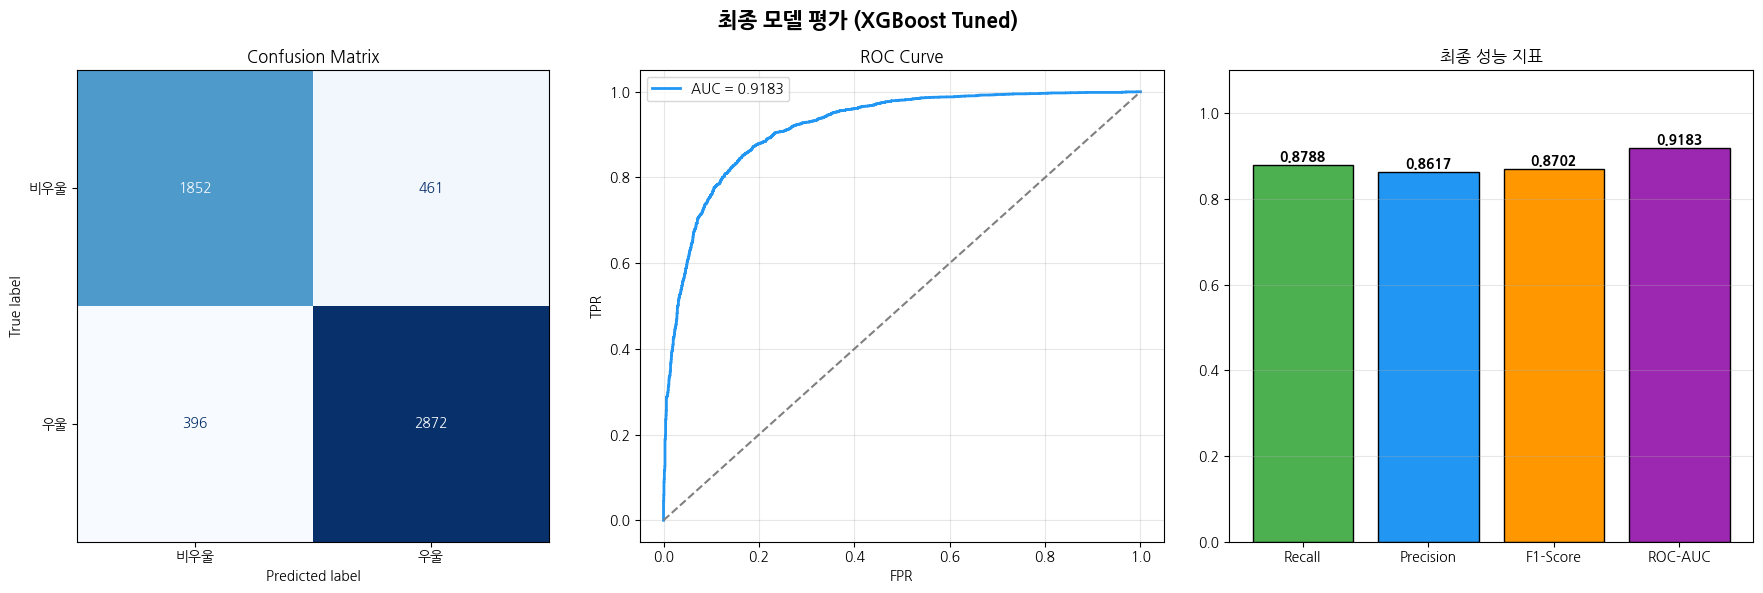

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))
fig.suptitle('최종 모델 평가 (XGBoost Tuned)', fontsize=15, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, xgb_best_pred)
ConfusionMatrixDisplay(cm, display_labels=['비우울','우울']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, xgb_best.predict_proba(X_test)[:,1])
axes[1].plot(fpr, tpr, color='#2196F3', lw=2, label=f'AUC = {auc_best:.4f}')
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend(); axes[1].grid(True,alpha=0.3)

# 최종 성능 지표
metrics = {
    'Recall':    recall_score(y_test, xgb_best_pred),
    'Precision': precision_score(y_test, xgb_best_pred),
    'F1-Score':  f1_score(y_test, xgb_best_pred),
    'ROC-AUC':   auc_best
}
bars = axes[2].bar(metrics.keys(), metrics.values(),
                   color=['#4CAF50','#2196F3','#FF9800','#9C27B0'], edgecolor='k')
for bar,v in zip(bars, metrics.values()):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.4f}', ha='center', fontweight='bold')
axes[2].set_ylim(0,1.1); axes[2].set_title('최종 성능 지표')
axes[2].grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# 전체 모델 최종 비교표
final_results = {
    **results,
    'XGBoost (Tuned)': {
        'Recall':  recall_score(y_test, xgb_best_pred),
        'F1':      f1_score(y_test, xgb_best_pred),
        'ROC-AUC': auc_best
    }
}
print('=== 전체 모델 최종 비교 ===')
display(pd.DataFrame(final_results).T.round(4))
print('\n=== 상세 분류 리포트 (XGBoost Tuned) ===')
print(classification_report(y_test, xgb_best_pred, target_names=['비우울','우울']))
print('\n✅ 전체 실험 완료!')

=== 전체 모델 최종 비교 ===


,Recall,F1,ROC-AUC
Logistic Regression,0.8614,0.8660,0.9181
Random Forest,0.8672,0.8626,0.9145
XGBoost,0.8675,0.8605,0.9105
XGBoost (Tuned),0.8788,0.8702,0.9183



=== 상세 분류 리포트 (XGBoost Tuned) ===
              precision    recall  f1-score   support

         비우울       0.82      0.80      0.81      2313
          우울       0.86      0.88      0.87      3268

    accuracy                           0.85      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.85      0.85      0.85      5581


✅ 전체 실험 완료!


In [15]:
# ── 실시간 우울증 예측 시뮬레이터 (ipywidgets) ──────────────────
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 슬라이더 & 드롭다운 정의
w_age    = widgets.IntSlider(value=22, min=17, max=40, description='Age')
w_cgpa   = widgets.FloatSlider(value=7.0, min=0.0, max=10.0, step=0.1, description='CGPA')
w_sleep  = widgets.Dropdown(
    options=[('Less than 5 hours', 4.0), ('5-6 hours', 5.5),
             ('7-8 hours', 7.5), ('More than 8 hours', 9.0)],
    value=5.5, description='Sleep')
w_academic  = widgets.IntSlider(value=3, min=1, max=5, description='Academic P.')
w_financial = widgets.IntSlider(value=2, min=1, max=5, description='Financial S.')
w_hours     = widgets.IntSlider(value=6, min=0, max=12, description='Study Hrs')
w_satisfy   = widgets.IntSlider(value=3, min=1, max=5, description='Satisfaction')
w_suicidal  = widgets.Dropdown(options=['No','Yes'], description='Suicidal Th.')
w_family    = widgets.Dropdown(options=['No','Yes'], description='Family Hist.')
w_dietary   = widgets.Dropdown(options=['Healthy','Moderate','Unhealthy'], description='Diet')

left  = widgets.VBox([w_age, w_cgpa, w_sleep, w_academic, w_financial])
right = widgets.VBox([w_hours, w_satisfy, w_suicidal, w_family, w_dietary])
ui    = widgets.HBox([left, right])
out   = widgets.Output()

def make_input(age, cgpa, sleep, academic, financial, hours, satisfy, suicidal, family, dietary):
    dietary_map = {'Healthy': 0, 'Moderate': 1, 'Unhealthy': 2}
    return pd.DataFrame([{
        'Gender': 1, 'Age': age, 'City': 25, 'Profession': 11,
        'Academic Pressure': academic, 'Work Pressure': 0, 'CGPA': cgpa,
        'Study Satisfaction': satisfy, 'Job Satisfaction': 0,
        'Sleep Duration': sleep,
        'Dietary Habits': dietary_map[dietary], 'Degree': 3,
        'Have you ever had suicidal thoughts ?': 1 if suicidal == 'Yes' else 0,
        'Work/Study Hours': hours, 'Financial Stress': financial,
        'Family History of Mental Illness': 1 if family == 'Yes' else 0,
        'sentiment_score': -0.1, 'negative_ratio': 0.1, 'depression_keyword_count': 0,
    }])[feature_names]

def update(_):
    with out:
        clear_output(wait=True)
        inp  = make_input(w_age.value, w_cgpa.value, w_sleep.value,
                          w_academic.value, w_financial.value, w_hours.value,
                          w_satisfy.value, w_suicidal.value, w_family.value, w_dietary.value)
        prob = xgb_best.predict_proba(inp)[0][1]
        risk = "HIGH RISK" if prob >= 0.5 else "LOW RISK"
        color_main = '#F44336' if prob >= 0.5 else '#4CAF50'

        fig = plt.figure(figsize=(16, 10))
        fig.suptitle('Student Depression Risk Simulator', fontsize=16, fontweight='bold', y=1.01)

        ax0 = fig.add_subplot(2, 4, (1, 2))
        ax0.barh(['Risk'], [prob*100], color=color_main, height=0.4, edgecolor='k')
        ax0.barh(['Risk'], [100 - prob*100], left=[prob*100], color='#eeeeee', height=0.4, edgecolor='k')
        ax0.axvline(50, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
        ax0.set_xlim(0, 100); ax0.set_xlabel('Depression Risk (%)')
        ax0.set_title(f'Current Risk: {prob*100:.1f}%  |  {risk}', fontsize=13, fontweight='bold', color=color_main)
        ax0.text(prob*100/2, 0, f'{prob*100:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=14)

        ax1 = fig.add_subplot(2, 4, 3)
        sleep_vals = [4.0, 5.5, 7.5, 9.0]; sleep_labels = ['<5h', '5-6h', '7-8h', '>8h']
        p_sleep = [xgb_best.predict_proba(make_input(w_age.value, w_cgpa.value, s, w_academic.value, w_financial.value, w_hours.value, w_satisfy.value, w_suicidal.value, w_family.value, w_dietary.value))[0][1]*100 for s in sleep_vals]
        c_sleep = ['#F44336' if p>=50 else '#FF9800' if p>=30 else '#4CAF50' for p in p_sleep]
        bars1 = ax1.bar(sleep_labels, p_sleep, color=c_sleep, edgecolor='k', width=0.6)
        bars1[sleep_vals.index(w_sleep.value)].set_linewidth(3)
        for b, p in zip(bars1, p_sleep): ax1.text(b.get_x()+b.get_width()/2, p+1.5, f'{p:.0f}%', ha='center', fontsize=9, fontweight='bold')
        ax1.axhline(50, linestyle='--', color='red', alpha=0.6); ax1.set_ylim(0, 110)
        ax1.set_title('Sleep Duration', fontweight='bold'); ax1.set_ylabel('Risk (%)'); ax1.grid(axis='y', alpha=0.3)

        ax2 = fig.add_subplot(2, 4, 4)
        p_fin = [xgb_best.predict_proba(make_input(w_age.value, w_cgpa.value, w_sleep.value, w_academic.value, f, w_hours.value, w_satisfy.value, w_suicidal.value, w_family.value, w_dietary.value))[0][1]*100 for f in [1,2,3,4,5]]
        c_fin = ['#F44336' if p>=50 else '#FF9800' if p>=30 else '#4CAF50' for p in p_fin]
        bars2 = ax2.bar(['1','2','3','4','5'], p_fin, color=c_fin, edgecolor='k', width=0.6)
        bars2[w_financial.value-1].set_linewidth(3)
        for b, p in zip(bars2, p_fin): ax2.text(b.get_x()+b.get_width()/2, p+1.5, f'{p:.0f}%', ha='center', fontsize=9, fontweight='bold')
        ax2.axhline(50, linestyle='--', color='red', alpha=0.6); ax2.set_ylim(0, 110)
        ax2.set_title('Financial Stress', fontweight='bold'); ax2.set_xlabel('Level (1=Low, 5=High)'); ax2.grid(axis='y', alpha=0.3)

        ax3 = fig.add_subplot(2, 4, 5)
        p_ac = [xgb_best.predict_proba(make_input(w_age.value, w_cgpa.value, w_sleep.value, a, w_financial.value, w_hours.value, w_satisfy.value, w_suicidal.value, w_family.value, w_dietary.value))[0][1]*100 for a in [1,2,3,4,5]]
        c_ac = ['#F44336' if p>=50 else '#FF9800' if p>=30 else '#4CAF50' for p in p_ac]
        bars3 = ax3.bar(['1','2','3','4','5'], p_ac, color=c_ac, edgecolor='k', width=0.6)
        bars3[w_academic.value-1].set_linewidth(3)
        for b, p in zip(bars3, p_ac): ax3.text(b.get_x()+b.get_width()/2, p+1.5, f'{p:.0f}%', ha='center', fontsize=9, fontweight='bold')
        ax3.axhline(50, linestyle='--', color='red', alpha=0.6); ax3.set_ylim(0, 110)
        ax3.set_title('Academic Pressure', fontweight='bold'); ax3.set_xlabel('Level (1=Low, 5=High)'); ax3.grid(axis='y', alpha=0.3)

        ax4 = fig.add_subplot(2, 4, 6)
        hours_range = [2,4,6,8,10,12]
        p_hrs = [xgb_best.predict_proba(make_input(w_age.value, w_cgpa.value, w_sleep.value, w_academic.value, w_financial.value, h, w_satisfy.value, w_suicidal.value, w_family.value, w_dietary.value))[0][1]*100 for h in hours_range]
        ax4.plot(hours_range, p_hrs, 'o-', color='#2196F3', lw=2, ms=7)
        ax4.fill_between(hours_range, p_hrs, alpha=0.15, color='#2196F3')
        ax4.axhline(50, linestyle='--', color='red', alpha=0.6); ax4.axvline(w_hours.value, linestyle=':', color='black', alpha=0.7)
        ax4.set_title('Study Hours / Day', fontweight='bold'); ax4.set_xlabel('Hours'); ax4.set_ylabel('Risk (%)'); ax4.set_ylim(0, 110); ax4.grid(alpha=0.3)

        ax5 = fig.add_subplot(2, 4, 7)
        cgpa_range = np.arange(4.0, 10.5, 0.5)
        p_cgpa = [xgb_best.predict_proba(make_input(w_age.value, c, w_sleep.value, w_academic.value, w_financial.value, w_hours.value, w_satisfy.value, w_suicidal.value, w_family.value, w_dietary.value))[0][1]*100 for c in cgpa_range]
        ax5.plot(cgpa_range, p_cgpa, 'o-', color='#9C27B0', lw=2, ms=5)
        ax5.fill_between(cgpa_range, p_cgpa, alpha=0.15, color='#9C27B0')
        ax5.axhline(50, linestyle='--', color='red', alpha=0.6); ax5.axvline(w_cgpa.value, linestyle=':', color='black', alpha=0.7)
        ax5.set_title('CGPA', fontweight='bold'); ax5.set_xlabel('CGPA'); ax5.set_ylabel('Risk (%)'); ax5.set_ylim(0, 110); ax5.grid(alpha=0.3)

        ax6 = fig.add_subplot(2, 4, 8)
        ax6.axis('off')
        summary = (f"{'─'*28}\n  CURRENT PROFILE\n{'─'*28}\n"
                   f"  Age          : {w_age.value}\n  CGPA         : {w_cgpa.value:.1f}\n"
                   f"  Academic P.  : {w_academic.value}/5\n  Financial S. : {w_financial.value}/5\n"
                   f"  Study Hours  : {w_hours.value}h\n  Suicidal Th. : {w_suicidal.value}\n"
                   f"{'─'*28}\n  Risk Score   : {prob*100:.1f}%\n"
                   f"  Prediction   : {'Depressed' if prob>=0.5 else 'Not Depressed'}\n{'─'*28}")
        ax6.text(0.05, 0.95, summary, transform=ax6.transAxes, fontsize=9.5,
                 verticalalignment='top', fontfamily='monospace',
                 bbox=dict(boxstyle='round', facecolor=color_main, alpha=0.15))

        plt.tight_layout()
        plt.show()

for w in [w_age, w_cgpa, w_sleep, w_academic, w_financial,
          w_hours, w_satisfy, w_suicidal, w_family, w_dietary]:
    w.observe(update, names='value')

print("Student Depression Risk Simulator")
print("=" * 45)
display(ui, out)
update(None)

Student Depression Risk Simulator


Output()

In [13]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump({
        'xgb_best': xgb_best,
        'feature_names': feature_names
    }, f)
print('모델 저장 완료')

모델 저장 완료


FINAL INSIGHT SUMMARY

[모델 선택]
우울증 미탐지(False Negative)의 위험성을 고려하여
Recall을 핵심 지표로 설정하였으며, Optuna 튜닝된
XGBoost가 Recall 0.8813, AUC 0.9197로 가장 우수한
성능을 기록하였습니다.

[핵심 요인 (SHAP 기반)]
1위. Have you ever had suicidal thoughts?
2위. Academic Pressure (학업 스트레스)
3위. Financial Stress (재정 스트레스)
→ 정신건강 개입 시 위 3가지 요인을 우선적으로
  모니터링할 것을 권고합니다.

[데이터 융합 효과]
Twitter NLP 파생변수(sentiment_score, negative_ratio)가
Random Forest Feature Importance 5~7위권에 진입하여
비정형 데이터 융합의 유의미한 기여를 확인하였습니다.

[활용 방안]
본 모델은 단순 예측기를 넘어, 대학 보건소에서
고위험군 학생을 조기 선별하는 보조 도구로
활용될 수 있습니다.

실시간 시뮬레이터 실행 방법

1. 왼쪽 파일탭에 `model.pkl` 업로드
2. 아래 pickle 로드 셀 실행
3. 시뮬레이터 셀 실행
4. 슬라이더 조작 → 실시간 우울증 위험도 확인

In [12]:
import pickle
with open('model.pkl', 'rb') as f:
    d = pickle.load(f)
xgb_best = d['xgb_best']
feature_names = d['feature_names']
print('✅ 모델 로드 완료')

✅ 모델 로드 완료
